# BÀI THỰC HÀNH 2: MẠNG NEURAL TÍCH CHẬP

<b>Hướng dẫn nộp bài:</b> Các bạn commit và push code lên github, sử dụng file txt đặt tên theo cú pháp <MSSV>.txt chứa đường link dẫn đến github của bài thực hành và nộp file txt này tên courses..

Bộ dữ liệu sử dụng: [VinaFood21 dataset](https://arxiv.org/abs/2108.02929).

Link download: https://drive.google.com/file/d/1UpZOf0XlwvB4rKpyZ35iwTA8oWHqDBbR/view?usp=share_link.

### Import libraries

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D, Dense, Flatten, Concatenate, Input, Dropout, BatchNormalization, Activation, Add
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

### Load data

In [63]:
# Load dữ liệu, chuẩn hóa (normalize) và reshape
INPUT_SHAPE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 21

train = ImageDataGenerator(rescale=1./255, validation_split=0.2).flow_from_directory(
    'vinafood21/train',
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val = ImageDataGenerator(rescale=1./255, validation_split=0.2).flow_from_directory(
    'vinafood21/train',
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'vinafood21/test',
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8051 images belonging to 21 classes.
Found 2003 images belonging to 21 classes.
Found 6683 images belonging to 21 classes.


### Bài 3*: Xây dựng mô hình ResNet-18, đánh giá mô hình ResNet-18 trên bộ dữ liệu VinaFood21 sử dụng các độ đo precision, recall, và F1 (Sử dụng Adam làm optimizer).

**ResNet Block**

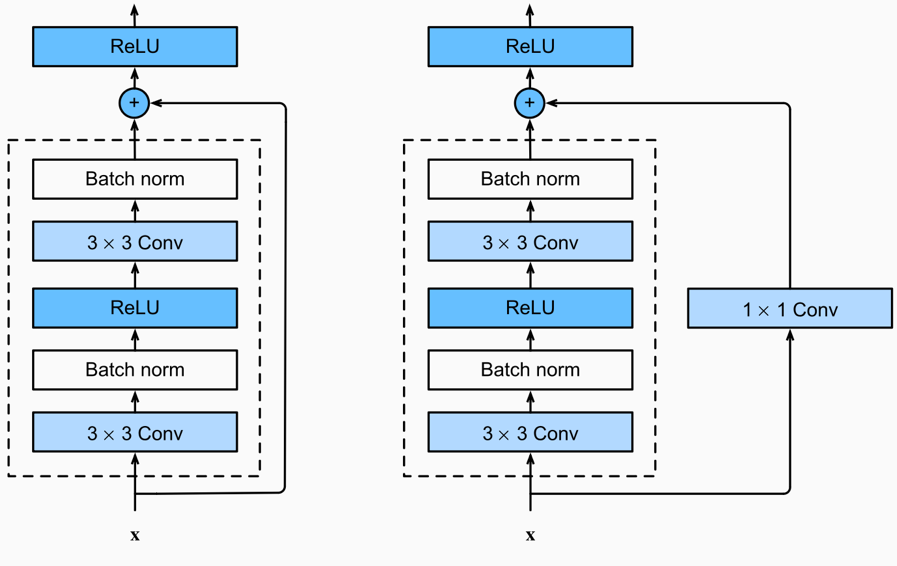

**ResNet**

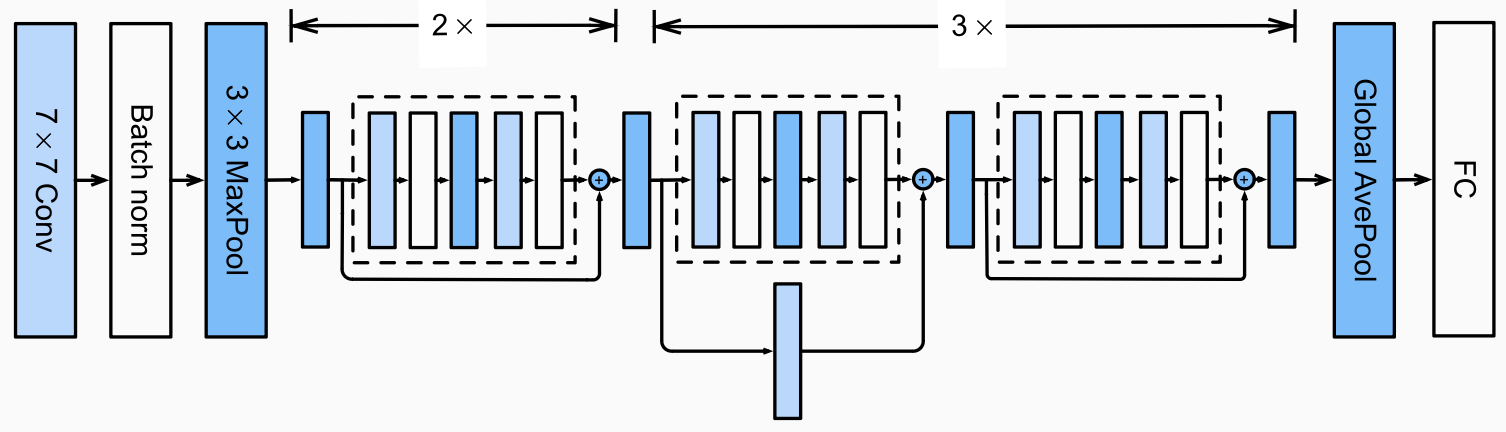

In [65]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = Conv2D(filters, (3,3), strides=stride, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    x = Conv2D(filters, (3,3), strides=1, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    if stride != 1 or K.int_shape(shortcut)[-1] != filters:
        shortcut = Conv2D(filters, (1,1), strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)
    
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def build_resnet18(input_shape, num_classes):
    input_shape=(input_shape[0], input_shape[1], 3)
    input_layer = Input(shape=input_shape)
    x = input_layer

    x = Conv2D(64, kernel_size=(7, 7), strides=2, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=2, padding='same')(x)

    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 64, stride=1)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128, stride=1)

    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256, stride=1)

    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512, stride=1)

    x = GlobalAveragePooling2D()(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    return model

In [66]:
resnet18 = build_resnet18(INPUT_SHAPE, NUM_CLASSES) 
resnet18.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_40 (Conv2D)            │ (None, 112, 112, 64)      │           9,408 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_40        │ (None, 112, 112, 64)      │             256 │ conv2d_40[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_34 (Activation)    │ (None, 112, 112, 64)      │               0 │ batch_normalization_40[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 56, 56, 64)        │               0 │ activation_34[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_41 (Conv2D)            │ (None, 56, 56, 64)        │          36,864 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_41        │ (None, 56, 56, 64)        │             256 │ conv2d_41[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_35 (Activation)    │ (None, 56, 56, 64)        │               0 │ batch_normalization_41[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_42 (Conv2D)            │ (None, 56, 56, 64)        │          36,864 │ activation_35[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_42        │ (None, 56, 56, 64)        │             256 │ conv2d_42[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_16 (Add)                  │ (None, 56, 56, 64)        │               0 │ batch_normalization_42[0]… │
│                               │                           │                 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_36 (Activation)    │ (None, 56, 56, 64)        │               0 │ add_16[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_43 (Conv2D)            │ (None, 56, 56, 64)        │          36,864 │ activation_36[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_43        │ (None, 56, 56, 64)        │             256 │ conv2d_43[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 11,196,885 (42.71 MB)

 Trainable params: 11,187,285 (42.68 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [67]:
# Biên dịch mô hình
resnet18.compile(
    optimizer=Adam(learning_rate=0.001), # Sử dụng Adam optimizer
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Định nghĩa EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

EPOCHS = 10

In [68]:
# Huấn luyện mô hình
history = resnet18.fit(
    train,
    epochs=EPOCHS,
    validation_data=val,
    callbacks=[early_stopping]
)

Epoch 1/10
158/252 ━━━━━━━━━━━━━━━━━━━━ 8:41 6s/step - accuracy: 0.1651 - loss: 3.1248 

C:\Users\PC\anaconda3\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


252/252 ━━━━━━━━━━━━━━━━━━━━ 1635s 6s/step - accuracy: 0.2298 - loss: 2.6308 - val_accuracy: 0.1168 - val_loss: 5.0752
Epoch 2/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 1541s 6s/step - accuracy: 0.2985 - loss: 2.2490 - val_accuracy: 0.0834 - val_loss: 5.7713
Epoch 3/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 827s 3s/step - accuracy: 0.3569 - loss: 2.0795 - val_accuracy: 0.1283 - val_loss: 8.8980
Epoch 4/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 767s 3s/step - accuracy: 0.3891 - loss: 1.9630 - val_accuracy: 0.1203 - val_loss: 6.5804
Epoch 5/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 706s 3s/step - accuracy: 0.4192 - loss: 1.8489 - val_accuracy: 0.2212 - val_loss: 3.3884
Epoch 6/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 708s 3s/step - accuracy: 0.4545 - loss: 1.7231 - val_accuracy: 0.2087 - val_loss: 3.3980
Epoch 7/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 700s 3s/step - accuracy: 0.4788 - loss: 1.6340 - val_accuracy: 0.2386 - val_loss: 3.3031
Epoch 8/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 704s 3s/step - accuracy: 0.5220 - loss: 1.5004 - val_accuracy: 0.3

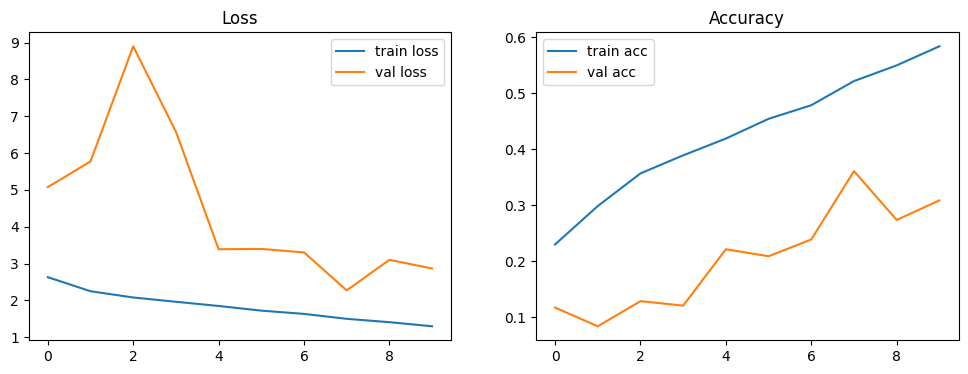

In [69]:
# Plot kết quả (accuracy và loss)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [70]:
# Đánh giá trên tập test
loss, acc = resnet18.evaluate(test, verbose=0)
test.reset()
Y_pred = resnet18.predict(test)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = test.classes 
class_names = list(test.class_indices.keys())

209/209 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step


In [71]:
# Báo cáo phân loại
report = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Macro Avg): {report['macro avg']['precision']:.4f}")
print(f"Recall (Macro Avg): {report['macro avg']['recall']:.4f}")
print(f"F1-score (Macro Avg): {report['macro avg']['f1-score']:.4f}")

print(classification_report(y_true, y_pred_classes, target_names=class_names))

Loss: 2.1698
Accuracy: 0.3489
Precision (Macro Avg): 0.4117
Recall (Macro Avg): 0.3329
F1-score (Macro Avg): 0.3089
                  precision    recall  f1-score   support

        banh-can       0.26      0.41      0.31       241
        banh-hoi       0.31      0.67      0.43       607
    banh-mi-chao       0.49      0.27      0.35       289
        banh-tet       0.29      0.65      0.40       364
 banh-trang-tron       0.24      0.15      0.19       309
          banh-u       0.67      0.15      0.24       176
        banh-uot       0.33      0.14      0.19       561
       bap-nuong       0.13      0.36      0.20       143
          bo-kho       0.40      0.49      0.44       338
       bo-la-lot       0.82      0.42      0.56       458
       bot-chien       0.19      0.07      0.10       276
           ca-ri       0.45      0.13      0.21       171
    canh-kho-qua       0.44      0.66      0.53       290
   canh-khoai-mo       0.41      0.84      0.55       198
        ga-nu

* Độ chính xác trên tập huấn luyện tăng từ 0.1651 lên 0.5843 sau 10 Epoch, đồng thời hàm mất mát huấn luyện giảm đáng kể từ 3.1248 xuống 1.2981. Tuy nhiên, hiệu suất trên tập val lại thấp hơn, với độ chính xác đạt 0.3085 và mất mát là 2.8664 ở Epoch cuối cùng. Sự chênh lệch lớn giữa hiệu suất train_accuracy: 0.5843 và val_accuracy: 0.3085 có thể là dấu hiệu của Overfitting.
* Báo cáo phân loại có độ chính xác chung là 0.3489 và Macro F1-score là 0.3089. Mặc dù một số lớp như bo-la-lot và canh-kho-qua có hiệu suất F1-score tương đối tốt (0.56 và 0.53), nhiều lớp khác lại gặp khó khăn nghiêm trọng, đặc biệt là các lớp có Recall rất thấp (tau-hu chỉ 0.06), cho thấy khả năng phân biệt kém đối với các danh mục đó.
* Để cải thiện, cần tập trung vào việc áp dụng các kỹ thuật chống quá khớp như điều chuẩn hình và tăng cường dữ liệu cho các lớp có hiệu suất thấp.